# K-Means - Analisis No Supervisado

Este notebook documenta el algoritmo no supervisado del proyecto. Se usa K-Means para segmentar vecindarios del dataset Boston Housing a partir de variables normalizadas.

## Justificacion

K-Means es pertinente porque el objetivo de este paso no es predecir `MEDV`, sino encontrar grupos de vecindarios con patrones similares. Como el algoritmo se basa en distancias, se usa el dataset normalizado generado por el pipeline.

In [7]:
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "params.yaml").exists():
    ROOT = ROOT.parent

mpl_config = ROOT / ".matplotlib_cache"
mpl_config.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(mpl_config)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

sns.set_theme(style="whitegrid")

with open(ROOT / "params.yaml", "r") as f:
    params = yaml.safe_load(f)

scaled_path = ROOT / params["data"]["model_ready"]["kmeans_scaled_path"]
clean_path = ROOT / params["data"]["processed_path"]
kmeans_params = params["modeling"]["kmeans"]

df_scaled = pd.read_csv(scaled_path)
df_clean = pd.read_csv(clean_path)

feature_cols = [
    col for col in df_scaled.columns
    if col not in kmeans_params["feature_exclude_columns"]
]
X = df_scaled[feature_cols]

print(f"Filas: {X.shape[0]}")
print(f"Variables usadas: {feature_cols}")

Filas: 506
Variables usadas: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


## Seleccion de variables

`MEDV` se excluye del entrenamiento porque es la variable objetivo del dataset. Usarla para crear clusters introduciria informacion de precio directamente en la segmentacion. El resto de variables explicativas se mantiene para que el algoritmo encuentre grupos usando patrones generales del vecindario.

## Metodo del codo

Se calcula la inercia para varios valores de `k`. El objetivo es elegir un numero de clusters que reduzca la distancia interna sin crear demasiados grupos dificiles de interpretar.

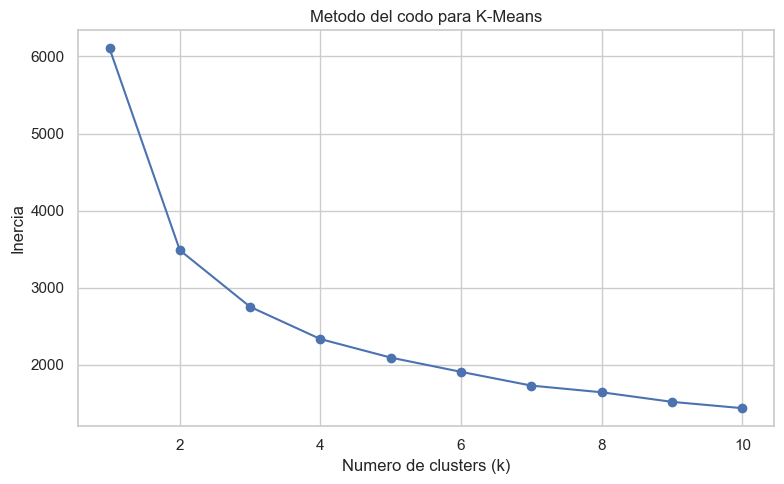

,k,inertia
0,1,6104.579051
1,2,3485.415460
2,3,2750.702704
3,4,2332.586168
4,5,2092.142327
5,6,1907.051977
6,7,1728.614931
7,8,1641.967901
8,9,1517.770777
9,10,1435.716174


In [8]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=kmeans_params["random_state"],
        init=kmeans_params["init"],
        n_init=kmeans_params["n_init"],
    )
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Inercia")
plt.title("Metodo del codo para K-Means")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(k_values), "inertia": inertias})

## Comparacion de random states

K-Means puede cambiar ligeramente por la inicializacion de centroides. Por eso se prueban varios `random_state` y se comparan inertia, silhouette score y tamano de clusters antes de seleccionar la configuracion final.

In [9]:
random_state_results = []
states_to_compare = kmeans_params.get("random_states_to_compare", [0, 21, 42, 77, 123])

for state in states_to_compare:
    model = KMeans(
        n_clusters=kmeans_params["n_clusters"],
        random_state=state,
        init=kmeans_params["init"],
        n_init=kmeans_params["n_init"],
    )
    labels = model.fit_predict(X)
    counts = pd.Series(labels).value_counts().sort_index()
    random_state_results.append({
        "random_state": state,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(X, labels),
        "cluster_0": counts.get(0, 0),
        "cluster_1": counts.get(1, 0),
        "cluster_2": counts.get(2, 0),
    })

random_state_comparison = pd.DataFrame(random_state_results).round(4)
random_state_comparison.sort_values(
    ["silhouette_score", "inertia"],
    ascending=[False, True]
)


,random_state,inertia,silhouette_score,cluster_0,cluster_1,cluster_2
0,0,2750.7027,0.3075,154,233,119
1,21,2750.7027,0.3075,119,154,233
2,42,2750.7027,0.3075,119,154,233
3,77,2750.7027,0.3075,154,233,119
4,123,2750.7027,0.3075,119,154,233


## Modelo final

El pipeline configura `k=3` y `random_state=42` en `params.yaml`. Esta configuracion se conserva como modelo final reproducible despues de comparar varios random states.

In [10]:
kmeans = KMeans(
    n_clusters=kmeans_params["n_clusters"],
    random_state=kmeans_params["random_state"],
    init=kmeans_params["init"],
    n_init=kmeans_params["n_init"],
)

clusters = kmeans.fit_predict(X)
df_clusters = df_clean.copy()
df_clusters["cluster"] = clusters

print(f"Inercia: {kmeans.inertia_:.4f}")
print(f"Silhouette score: {silhouette_score(X, clusters):.4f}")
df_clusters["cluster"].value_counts().sort_index()

Inercia: 2750.7027
Silhouette score: 0.3075


cluster
0    119
1    154
2    233
Name: count, dtype: int64

## Diagrama de silueta

El diagrama de silueta muestra que tan bien encaja cada observacion dentro de su cluster. Valores cercanos a 1 indican buena separacion, valores cercanos a 0 indican puntos entre clusters y valores negativos sugieren posible asignacion incorrecta.

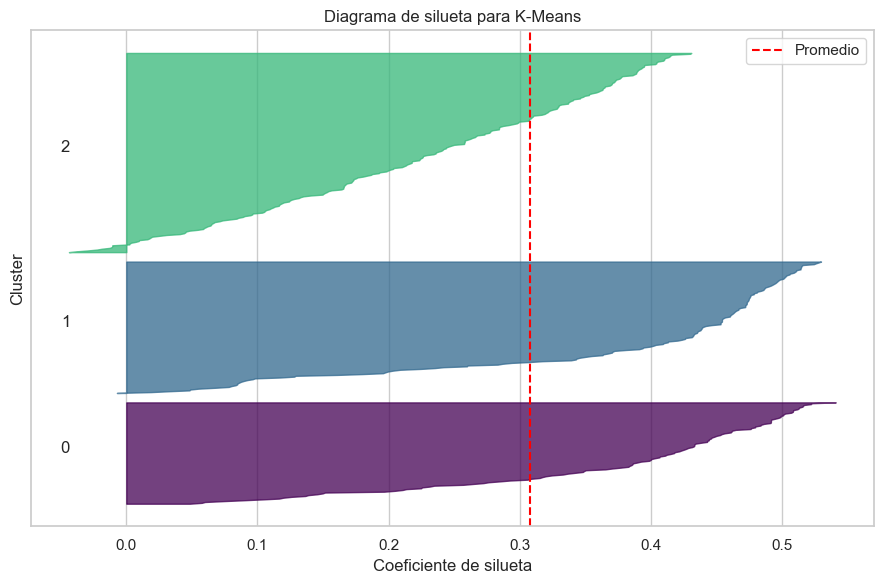

Silhouette score promedio: 0.3075


In [11]:
sample_silhouette_values = silhouette_samples(X, clusters)
avg_silhouette = silhouette_score(X, clusters)

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10

for cluster_id in range(kmeans_params["n_clusters"]):
    cluster_values = sample_silhouette_values[clusters == cluster_id]
    cluster_values.sort()

    cluster_size = cluster_values.shape[0]
    y_upper = y_lower + cluster_size
    color = plt.cm.viridis(float(cluster_id) / kmeans_params["n_clusters"])

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.75,
    )
    ax.text(-0.05, y_lower + 0.5 * cluster_size, str(cluster_id))
    y_lower = y_upper + 10

ax.axvline(x=avg_silhouette, color="red", linestyle="--", label="Promedio")
ax.set_title("Diagrama de silueta para K-Means")
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Cluster")
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

print(f"Silhouette score promedio: {avg_silhouette:.4f}")


## Perfil de clusters

La tabla resume el promedio de cada variable por cluster. Esta vista permite interpretar que caracteristicas distinguen a cada segmento.

In [12]:
cluster_profile = df_clusters.groupby("cluster").mean(numeric_only=True).round(3)
cluster_profile["count"] = df_clusters["cluster"].value_counts().sort_index()
cluster_profile

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,count
cluster,,,,,,,,,,,,,,,
0,0.086,26.79,4.232,0.050,0.432,6.637,35.827,6.461,4.370,294.815,17.230,389.767,6.804,28.155,119
1,6.630,0.00,18.606,0.078,0.689,5.974,90.666,2.003,21.240,638.870,19.674,368.805,18.813,16.226,154
2,0.406,1.44,9.726,0.073,0.528,6.290,70.699,3.594,4.468,313.730,18.294,386.578,11.480,23.830,233


## Visualizacion

`LSTAT` y `RM` se usan como ejes de visualizacion porque suelen tener una relacion fuerte con `MEDV` y ayudan a interpretar los segmentos. El modelo, sin embargo, se entrena con todas las variables explicativas normalizadas.

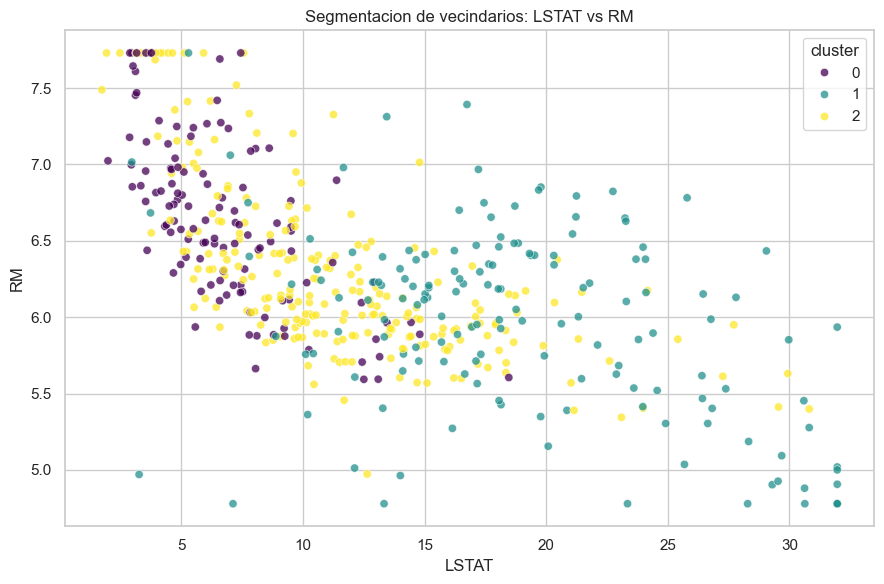

In [13]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_clusters,
    x="LSTAT",
    y="RM",
    hue="cluster",
    palette="viridis",
    alpha=0.75,
)
plt.title("Segmentacion de vecindarios: LSTAT vs RM")
plt.tight_layout()
plt.show()

## Conclusiones

K-Means permite identificar tres perfiles generales de vecindarios sin usar directamente el precio como variable de entrenamiento. La normalizacion previa es necesaria para que variables con rangos grandes, como `TAX` o `ZN`, no dominen artificialmente las distancias. El pipeline usa un dataset model-ready especifico para K-Means en `data/model_ready/kmeans/`, compara diferentes random states y evalua la separacion con silhouette score y diagrama de silueta. La segmentacion se interpreta con ayuda de variables como `LSTAT`, `RM`, `CRIM` y `MEDV`, pero `MEDV` solo se usa despues del entrenamiento para describir los clusters.